## Imports

In [1]:
import MDAnalysis as mda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from MDAnalysis.lib.distances import distance_array
from MDAnalysis import units
from MDAnalysis.analysis import rdf

from openmm.unit import Quantity, Unit
from openmm.unit import kelvin, bar, litre, kilojoule_per_mole, mole, nanometer, angstrom, kilocalorie_per_mole
from openmm.unit import AVOGADRO_CONSTANT_NA, BOLTZMANN_CONSTANT_kB
R = BOLTZMANN_CONSTANT_kB * AVOGADRO_CONSTANT_NA # gas constant

import quantities
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
from pymbar import timeseries
from MDAnalysis.analysis import density
from tqdm import tqdm
import os
import json
from scipy.optimize import least_squares,minimize
from scipy.integrate import simpson


/tmp/ipykernel_363682/2335017174.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*            

## Set working directory

In [2]:
# ffs=input("Which force fields? (Options: JC, CHARMM27)")
# os.chdir("/home/bamo6610/Documents/GROMACS_files/MDAnalysis/SPW_ALL/%s"%ffs)

# os.chdir("/home/bamo6610/Documents/openff-dev/HW_openMM/blanca_analysis")

## Loading data and creating atom group of ions

In [3]:
### 3.5 molal ##
u = mda.Universe('md.pdb', 'md.xtc')
u.transfer_to_memory()
ions= u.select_atoms('resname NA CL')

u1 = mda.Universe('mdr1.pdb', 'mdr1.xtc')
u1.transfer_to_memory()
ions1= u1.select_atoms('resname NA CL')

u2 = mda.Universe('mdr2.pdb', 'mdr2.xtc')
u2.transfer_to_memory()
ions2= u2.select_atoms('resname NA CL')

u3 = mda.Universe('mdr3.pdb', 'mdr3.xtc')
u3.transfer_to_memory()
ions3= u3.select_atoms('resname NA CL')

## Density profiles using MDanalysis

In [4]:
def density_profile(universe, atom_group, bin_width=0.5, dim='z', method='atom', frameby=1):
    '''Calculate the partial density across the box'''

    if isinstance(atom_group, str): # if provided selection language, make AtomGroup
        ag = universe.select_atoms(atom_group)
    else: # else assume input is AtomGroup
        ag = atom_group

    print(f'\nCalculating the partial density profile of {atom_group} in the {dim} dimension...')

    dims = {'x': 0, 'y': 1, 'z': 2}
    d = dims[dim]
    box = universe.dimensions[d]

    n_bins = int(box / bin_width)
    bins = np.linspace(0, box, num=n_bins)

    counts = np.zeros(n_bins)
        
    if len(universe.trajectory) == 0:
        for b in tqdm(range(n_bins-1)):
            lb = bins[b]
            ub = bins[b+1]
            bin_atoms = universe.select_atoms(f'prop {dim} > {lb} and prop {dim} < {ub} and group ag', ag=ag)
            if method in ['atom', 'atoms', 'all']:
                counts[b] += len(bin_atoms)
            elif method in ['molecule', 'mol', 'residue', 'res']: 
                counts[b] += bin_atoms.n_residues
            elif method in ['mass', 'mass density']:
                box_dims = [box[i] for i in range(3) if i != d]
                dV = box_dims[0] * box_dims[1] * (ub-lb) * (10**-8)**3
                mass = bin_atoms.masses.sum() / 6.022 / 10**23
                counts[b] += mass / dV
    else:
        for ts in tqdm(universe.trajectory[::frameby]):
            for b in range(n_bins-1):
                lb = bins[b]
                ub = bins[b+1]
                bin_atoms = universe.select_atoms(f'prop {dim} > {lb} and prop {dim} < {ub} and group ag', ag=ag)

                if method in ['atom', 'atoms', 'all', 'number']:
                    counts[b] += len(bin_atoms)                 
                elif method in ['molecule', 'mol', 'residue', 'res']: 
                    counts[b] += bin_atoms.n_residues
                elif method in ['mass', 'mass density']:
                    box_dims = [box[i] for i in range(3) if i != d]
                    dV = box_dims[0] * box_dims[1] * (ub-lb) * (10**-8)**3
                    mass = bin_atoms.masses.sum() / 6.022 / 10**23
                    counts[b] += mass / dV

        counts = counts / len(universe.trajectory[::frameby])

    return bins/10, counts

In [5]:
nbins,ncounts=density_profile(u,ions)
nbins1,ncounts1=density_profile(u1,ions1)
nbins2,ncounts2=density_profile(u2,ions2)
nbins3,ncounts3=density_profile(u3,ions3)


Calculating the partial density profile of <AtomGroup [<Atom 11101: Na00 of type Na of resname NA, resid 1 and segid I and altLoc >, <Atom 11102: Na01 of type Na of resname NA, resid 1 and segid J and altLoc >, <Atom 11103: Na02 of type Na of resname NA, resid 1 and segid K and altLoc >, ..., <Atom 11532: Cl21 of type Cl of resname CL, resid 1 and segid X and altLoc >, <Atom 11533: Cl21 of type Cl of resname CL, resid 1 and segid Y and altLoc >, <Atom 11534: Cl21 of type Cl of resname CL, resid 1 and segid Z and altLoc >]> in the z dimension...


100%|██████████| 250/250 [02:26<00:00,  1.70it/s]



Calculating the partial density profile of <AtomGroup [<Atom 11101: Na00 of type Na of resname NA, resid 1 and segid I and altLoc >, <Atom 11102: Na01 of type Na of resname NA, resid 1 and segid J and altLoc >, <Atom 11103: Na02 of type Na of resname NA, resid 1 and segid K and altLoc >, ..., <Atom 11532: Cl21 of type Cl of resname CL, resid 1 and segid X and altLoc >, <Atom 11533: Cl21 of type Cl of resname CL, resid 1 and segid Y and altLoc >, <Atom 11534: Cl21 of type Cl of resname CL, resid 1 and segid Z and altLoc >]> in the z dimension...


100%|██████████| 250/250 [02:31<00:00,  1.65it/s]



Calculating the partial density profile of <AtomGroup [<Atom 11101: Na00 of type Na of resname NA, resid 1 and segid I and altLoc >, <Atom 11102: Na01 of type Na of resname NA, resid 1 and segid J and altLoc >, <Atom 11103: Na02 of type Na of resname NA, resid 1 and segid K and altLoc >, ..., <Atom 11532: Cl21 of type Cl of resname CL, resid 1 and segid X and altLoc >, <Atom 11533: Cl21 of type Cl of resname CL, resid 1 and segid Y and altLoc >, <Atom 11534: Cl21 of type Cl of resname CL, resid 1 and segid Z and altLoc >]> in the z dimension...


100%|██████████| 250/250 [02:27<00:00,  1.70it/s]



Calculating the partial density profile of <AtomGroup [<Atom 11101: Na00 of type Na of resname NA, resid 1 and segid I and altLoc >, <Atom 11102: Na01 of type Na of resname NA, resid 1 and segid J and altLoc >, <Atom 11103: Na02 of type Na of resname NA, resid 1 and segid K and altLoc >, ..., <Atom 11532: Cl21 of type Cl of resname CL, resid 1 and segid X and altLoc >, <Atom 11533: Cl21 of type Cl of resname CL, resid 1 and segid Y and altLoc >, <Atom 11534: Cl21 of type Cl of resname CL, resid 1 and segid Z and altLoc >]> in the z dimension...


100%|██████████| 250/250 [02:28<00:00,  1.68it/s]


### Density plots

In [6]:
NA = 6.02214076E23  # Avogadro's number
Ntrue = 217 #Number of ions used
N_s = 217 #Number of ions used
k = 0.785  # units: kJ/mol/nm^2 - force constant being used in calculations
R = 8.31446261815324  # units: J/(mol*K) - ideal gas constant
T = 300  # units: K - temperature used for calculations
L_x, L_y, L_z = 4.8, 4.8, 14.4

In [7]:
print(len(nbins))
print(len(ncounts))
print(len(ions)/2)

288
288
217.0


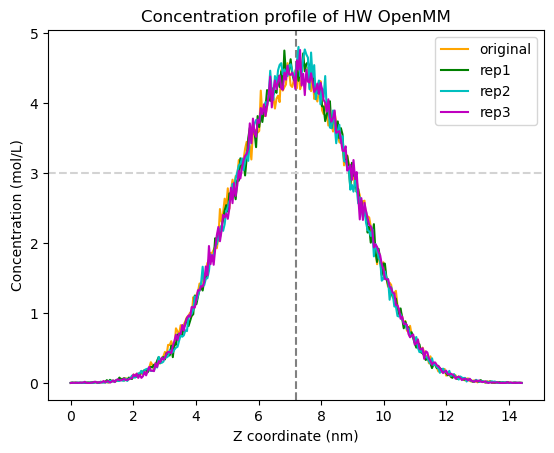

In [8]:
plt.axvline(x = 7.2, color = 'gray', linestyle = 'dashed')
plt.axhline(y = 3, color = 'lightgray', linestyle = 'dashed')
plt.plot(nbins,ncounts, c='orange', label='original')
plt.plot(nbins1,ncounts1, c='g', label='rep1')
plt.plot(nbins2,ncounts2, c='c', label='rep2')
plt.plot(nbins3,ncounts3, c='m', label='rep3')

plt.xlabel("Z coordinate (nm)")
plt.ylabel("Concentration (mol/L)")
plt.title("Concentration profile of HW OpenMM")
plt.legend()
plt.show()

In [9]:
data_to_save = np.column_stack((nbins, ncounts))
np.savetxt('density_hw_35_original.txt', data_to_save, fmt='%.3f')

In [10]:
data_to_save1 = np.column_stack((nbins1, ncounts1))
np.savetxt('density_hw_35_r1.txt', data_to_save1, fmt='%.3f')

In [11]:
data_to_save2 = np.column_stack((nbins2, ncounts2))
np.savetxt('density_hw_35_r2.txt', data_to_save2, fmt='%.3f')

In [12]:
data_to_save3 = np.column_stack((nbins3, ncounts3))
np.savetxt('density_hw_35_r3.txt', data_to_save, fmt='%.3f')

In [13]:
def compute_c_profile(xvg_file):
    """
    Computes a concentration profile from an XVG file by averaging symmetric parts of the profile.

    Parameters
    ----------
    xvg_file : str
        The path to the XVG file containing the number density data.
    
    Returns
    -------
    z_coords : numpy.ndarray
        The z-coordinates of the concentration profile.
    c_profile : numpy.ndarray
        The symmetric concentration profile.
    """
    z_coords, rho = np.loadtxt(xvg_file, comments=["@", "#"], unpack=True)
    # rho = rho / NA * 1E27 / 1000  # number density in mol/L

    mid_idx = int(len(rho) / 2 - 1)
    c_profile = 0.5 * (rho[:mid_idx + 1][::-1] + rho[mid_idx:-1])  # in mol/L
    z_coords = z_coords[:mid_idx + 1]  # in nm

    return z_coords, c_profile


In [14]:
z, c_original = compute_c_profile("density_hw_35_original.txt")
z, c_1 = compute_c_profile("density_hw_35_r1.txt")  # replicate 1
z, c_2 = compute_c_profile("density_hw_35_r2.txt")  # replicate 2
z, c_3 = compute_c_profile("density_hw_35_r3.txt")  # replicate 3

In [15]:
# List concentration profiles
concentration_profiles = np.array([c_original,c_1,c_2,c_3])

In [16]:
# Estimate the total number of ions, N_s (using Equation 13)

for c in concentration_profiles:
    N_s = L_x * L_y * simpson(c, x=z)
    print(N_s)  # this should compare to number of ions used (3m used 188)
    c /= (N_s/Ntrue)
    
# verify normalization worked.
for c in concentration_profiles:
    N_s = L_x * L_y * simpson(c, z)
    print(N_s)  # compare to number of ions used (3m used 188)
    

250.91873398362353
251.05262082164887
250.7312303730805
250.91873398362353
216.99999999999991
217.0
216.99999999999997
216.99999999999991


/tmp/ipykernel_363682/609993702.py:10: DeprecationWarning: You are passing x=[0.    0.05  0.1   0.151 0.201 0.251 0.301 0.351 0.401 0.452 0.502 0.552
 0.602 0.652 0.702 0.753 0.803 0.853 0.903 0.953 1.004 1.054 1.104 1.154
 1.204 1.254 1.305 1.355 1.405 1.455 1.505 1.556 1.606 1.656 1.706 1.756
 1.806 1.857 1.907 1.957 2.007 2.057 2.107 2.158 2.208 2.258 2.308 2.358
 2.409 2.459 2.509 2.559 2.609 2.659 2.71  2.76  2.81  2.86  2.91  2.961
 3.011 3.061 3.111 3.161 3.211 3.262 3.312 3.362 3.412 3.462 3.512 3.563
 3.613 3.663 3.713 3.763 3.814 3.864 3.914 3.964 4.014 4.064 4.115 4.165
 4.215 4.265 4.315 4.366 4.416 4.466 4.516 4.566 4.616 4.667 4.717 4.767
 4.817 4.867 4.917 4.968 5.018 5.068 5.118 5.168 5.219 5.269 5.319 5.369
 5.419 5.469 5.52  5.57  5.62  5.67  5.72  5.771 5.821 5.871 5.921 5.971
 6.021 6.072 6.122 6.172 6.222 6.272 6.322 6.373 6.423 6.473 6.523 6.573
 6.624 6.674 6.724 6.774 6.824 6.874 6.925 6.975 7.025 7.075 7.125 7.176] as a positional argument. Please change your i

In [17]:
print(N_s)

216.99999999999991


## Calculating eq 12

## Calculating eq 12

$$ ln \left[ \frac{C_{s}(z)}{C_{max}} \right] + A \left[ \frac{C_{max}^{1/2}}{1+BC_{max}^{1/2}} - \frac{C_{s}(z)^{1/2}}{1+BC_{s}(z)^{1/2}} \right] + \sum^{i_{max}}_{i=1} \alpha_{i} [C_{s}(z)^{i} - C_{max}^{i}] = - \frac {U(z)}{RT}$$

In [18]:
def calc_y(theta, x):
    """
    Calculates -U(z) / RT using Equation 12.

    Parameters
    ----------
    theta : list
        A list containing the three parameters to be fit, including B, alpha_1, alpha_2.
    x : concentration list
    """
    A = 1.7964  # in M^(-1/2), value according to the SI

    # Converting the units for A so that they are nm-based
    conversion_factor = 1E24 / NA  # 1 nm^(-3) ~= 1.6605 M
    A /= (conversion_factor ** 0.5)

    C_max = np.max(x)
    term_1 = np.log(x / C_max)
    term_2 = -A * np.sqrt(x) / (1 + theta[0] * np.sqrt(x))
    term_3 = A * np.sqrt(C_max) / (1 + theta[0] * np.sqrt(C_max))
    term_4 = theta[1]* (x - C_max) 
    term_5 = theta[2] * (x ** 2 - C_max ** 2)
    y = term_1 + term_2 + term_3 + term_4 + term_5

    return y

def residuals(theta, x, y):
    return np.power(np.subtract(calc_y(theta, x),y), 2)

In [19]:
#Use the direct average rather than over bootstrap means
mean_profile = np.mean(concentration_profiles,axis=0)
c_0 = mean_profile

# Removing 0 values from the concentration profile, and the corresponding z values
z_fit = z[c_0 != 0]
c_fit = c_0[c_0 != 0]

In [20]:
A = 1.7964  # in M^(-1/2), value according to the SI

# Converting the units for A so that they are nm-based
conversion_factor = 1E24 / NA  # 1 nm^(-3) ~= 1.6605 M
A /= (conversion_factor ** 0.5)

In [21]:
# Right side/ y of equation 12
y_values = -(0.5 * k * z_fit ** 2) * 1000 / (R * T) 

#Getting fit for full left side of eq 12
result_unweighted = least_squares(residuals, [4, 0.2, 0], args=(c_fit, y_values))

## Plotting unweighted results

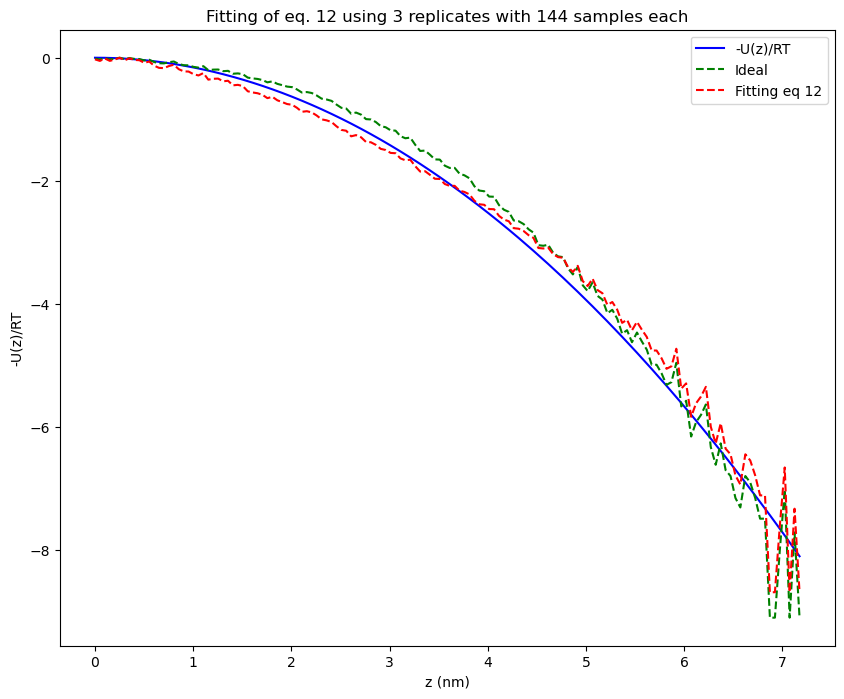

In [22]:
# plot the unweighted results
plt.figure(figsize = (10,8))
plt.plot(z_fit, y_values, 'b', label="-U(z)/RT")
plt.plot(z_fit, np.log(c_fit/np.max(c_fit)), 'g--', label="Ideal")
plt.plot(z_fit, calc_y(result_unweighted.x,c_fit), 'r--', label="Fitting eq 12")
plt.xlabel('z (nm)')
plt.ylabel('-U(z)/RT')
plt.title('Fitting of eq. 12 using 3 replicates with 144 samples each')
plt.legend()
plt.show()

We do see reasonably good fit - the idea curve (green line) is corrected to the be closer to the blue (red line is closer tothe blue line). However, we would also like to not fit the noise at the end. 

To do this, we do some error propagation to find the ideal weights for the least square fit. $C(z)/C_{max}$ is a probability, or at least proportional to a probability.  The uncertainty in a probability estimate $\hat{p}$ from a histogram (whose value with infinitely collected points would be $p$), can be shown to be $\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$, where $\hat{p}$ is the measured probability in that histogram bin, and $n$ is the total number of points collected over all bins.  But we are interested in the error of $\ln \hat{p}$. Generally the error in function $f$ of random variable $x$ $\delta f(x)$ is equal to $|f'(x)| \delta x$. So $\delta (\ln p) = \frac{\delta p}{p} = \sqrt{\frac{\hat{p}(1-\hat{p})}{n\hat{p}^2}}$.

For weighted least squares, it can be show that the weights should be proportional to 1/variance of the data point. The variance will be $(\delta\ln p)^2 = \frac{\hat{p}(1-\hat{p})}{n\hat{p}^2} = \frac{1-\hat{p}}{np}$.  The weights are only defined up to a constant, so we can just use $\frac{1-p}{p}$.  To do this, we have to normalize $C/C_{max}$, which is easy to do, we call it K. So the weights should be proportional to $\frac{C/K}{1-C/K} = \frac{C}{K-C}$.  So the most well defined points will get the most probability, the noisiest points the least.

## Find weights for least square fit

In [23]:
norm = N_s/(L_x*L_y)
print(norm)

9.418402777777775


In [24]:
def weighted_residuals(theta, x, y):
    return (x/(norm-x))*np.power(np.subtract(calc_y(theta, x),y), 2)

In [25]:
#Getting fit for full left side of eq 12
result_weighted = least_squares(weighted_residuals, [4, 0.2,-0.01], args=(c_fit, y_values))

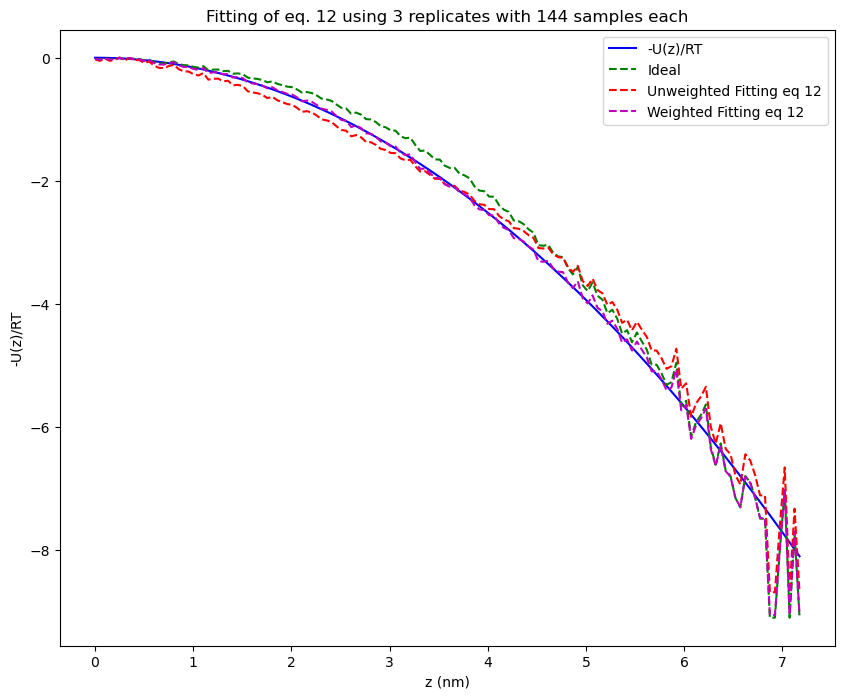

In [26]:
# plot the results
plt.figure(figsize = (10,8))
plt.plot(z_fit, y_values, 'b', label="-U(z)/RT")
plt.plot(z_fit, np.log(c_fit/np.max(c_fit)), 'g--', label="Ideal")
plt.plot(z_fit, calc_y(result_unweighted.x,c_fit), 'r--', label="Unweighted Fitting eq 12")
plt.plot(z_fit, calc_y(result_weighted.x,c_fit), 'm--', label="Weighted Fitting eq 12")
plt.xlabel('z (nm)')
plt.ylabel('-U(z)/RT')
plt.title('Fitting of eq. 12 using 3 replicates with 144 samples each')
plt.legend()
plt.show()

Hard to see what is going on, so let's look at differences

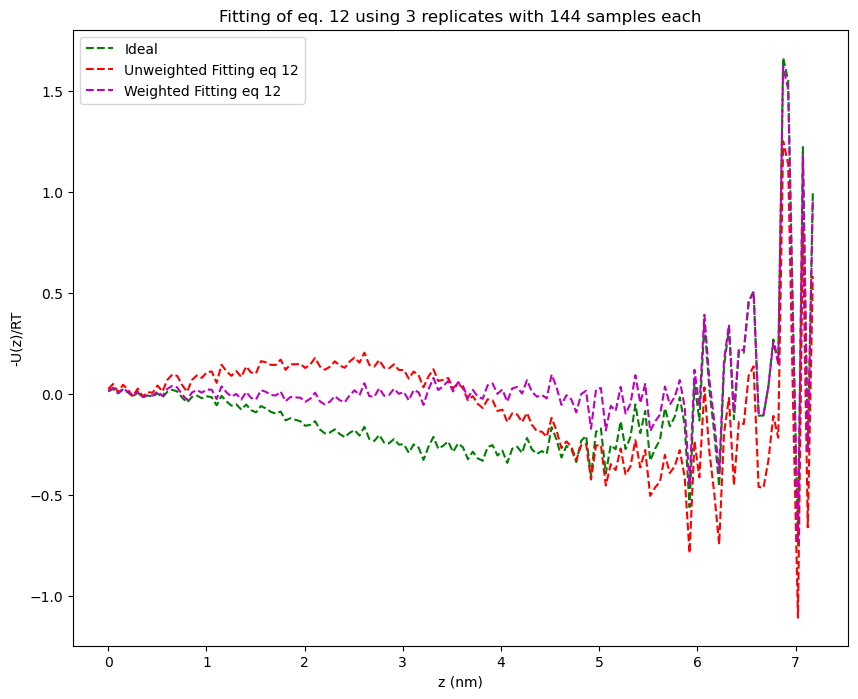

In [27]:
# plot the results. Notice the plots are now being subtracted from the y_values results
plt.figure(figsize = (10,8))
plt.plot(z_fit, y_values-np.log(c_fit/np.max(c_fit)), 'g--', label="Ideal")
plt.plot(z_fit, y_values-calc_y(result_unweighted.x,c_fit), 'r--', label="Unweighted Fitting eq 12")
plt.plot(z_fit, y_values-calc_y(result_weighted.x,c_fit), 'm--', label="Weighted Fitting eq 12")
plt.xlabel('z (nm)')
plt.ylabel('-U(z)/RT')
plt.title('Fitting of eq. 12 using 3 replicates with 144 samples each')
plt.legend()
plt.show()

The weighted fitting is much closer to zero over the range with reasonable concentrations, say z=5.

In [28]:
zlim = 4 #coordinate limit for where fitting is closer

In [29]:
#Stdev of unweighted results
np.std(y_values[z_fit<zlim]-calc_y(result_unweighted.x,c_fit[z_fit<zlim]))

0.06467563369317485

In [30]:
#Stdev of weighted results
np.std(y_values[z_fit<zlim]-calc_y(result_weighted.x,c_fit[z_fit<zlim]))

0.027132285053230513

Compare the distribution of the parameters with the fit!

In [31]:
print("B =", result_unweighted.x[0])
print("alpha1 =", result_unweighted.x[1])
print("alpha2 =", result_unweighted.x[2])

B = 0.00022772730186608475
alpha1 = 0.5991728814134545
alpha2 = -0.0014410213185432957


In [32]:
print("B =", result_weighted.x[0])
print("alpha1 =", result_weighted.x[1])
print("alpha2 =", result_weighted.x[2])

B = 1.3097884227364407
alpha1 = 0.2791415104797108
alpha2 = -0.02576868558728568


And we expect that the parameters will be more consistent between runs with weighting.

## Bootstrapping Profiles (without and with weights)

In [33]:
trialp = [4, 0.1,0.0]

In [34]:
# Function to perform bootstrapping
def bootstrap_profiles(profiles, n_samples, res_func):
    bootstrap_params = []
    n_profiles = len(profiles)
    for _ in range(n_samples):
        # Resample with replacement
        bootstrap_sample = [profiles[np.random.randint(0, n_profiles)] for _ in range(n_profiles)]
        # Calculate mean profile
        mean_profile = np.mean(bootstrap_sample, axis=0)
        z_fit = z[mean_profile != 0]
        c_fit = mean_profile[mean_profile != 0] 
        y_values = -(0.5 * k * z_fit ** 2) * 1000 / (R * T)
        result = least_squares(res_func, trialp, args=(c_fit, y_values))
        bootstrap_params.append(result.x)
        
    return np.array(bootstrap_params) # list

Param 0 = 0.0023863998323312642 +/- 0.05227266607594843


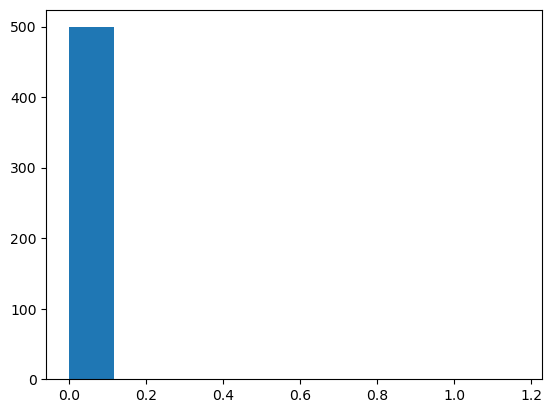

Param 1 = 0.7115850374933811 +/- 0.1388964937113012


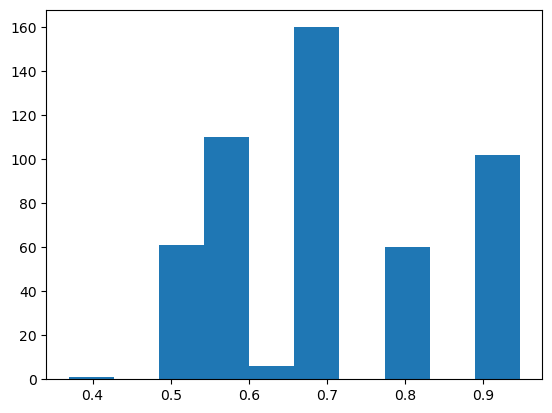

Param 2 = -0.025116358018531834 +/- 0.028791828425245494


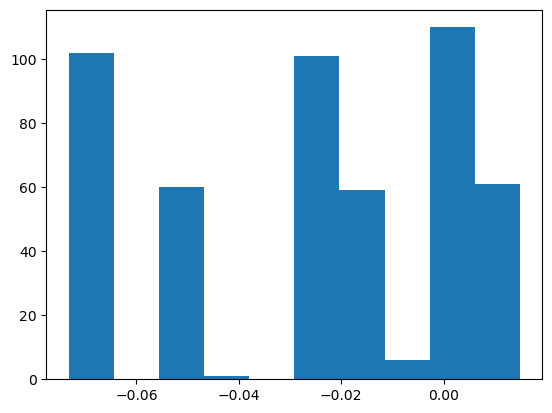

In [35]:
# Perform bootstrapping with unweighted fit
bootstrap_params_unweighted = bootstrap_profiles(profiles=concentration_profiles, n_samples=500, res_func=residuals)

for i in range(len(trialp)):
    pd = bootstrap_params_unweighted[:,i]
    std_param = np.std(pd) 
    mean_param = np.mean(pd)  # it's actually more accurate to
                             # just use the single fits, but we don't 
                             # necessarily know the name of that results structure
                             # when we are at this point in the code, use the mean for now
    print(f"Param {i} = {mean_param} +/- {std_param}")
    plt.hist(pd)
    plt.show()

Param 0 = 1.1168715376171634 +/- 0.36210696180724583


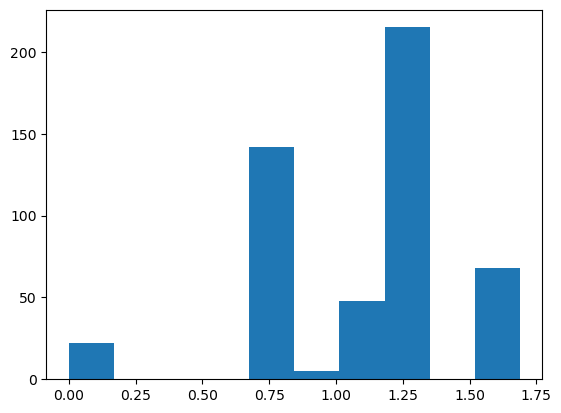

Param 1 = 0.3454680066859323 +/- 0.1369989291732909


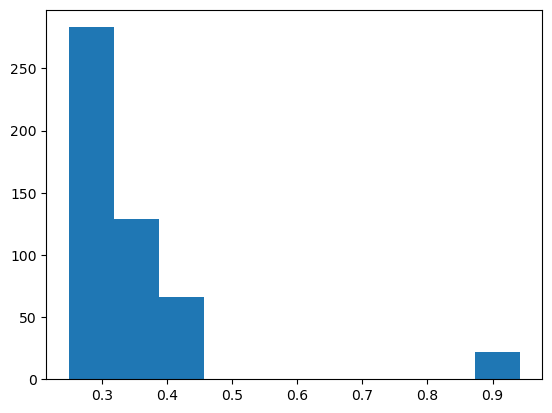

Param 2 = -0.033141402882570815 +/- 0.009840915965506857


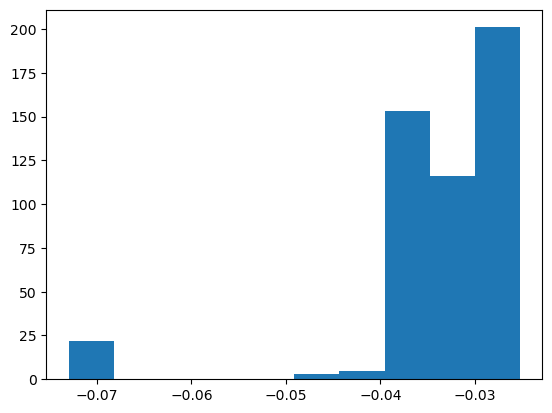

In [36]:
# Perform bootstrapping with weighted residuals
n_bootstrap = 500
bootstrap_params_weighted  = bootstrap_profiles(profiles=concentration_profiles, n_samples=500, res_func=weighted_residuals)

for i in range(len(trialp)):
    pd = bootstrap_params_weighted[:,i]
    std_param = np.std(pd) 
    mean_param = np.mean(pd)  # it's actually more accurate to
                             # just use the single fits, but we don't 
                             # necessarily know the name of that results structure
                             # when we are at this point in the code, use the mean for now
    print(f"Param {i} = {mean_param} +/- {std_param}")
    plt.hist(pd)
    plt.show()

Much more consistent performance!

$$ ln \left[ \frac{C_{s}(z)}{C_{max}} \right] + A \left[ \frac{C_{max}^{1/2}}{1+BC_{max}^{1/2}} - \frac{C_{s}(z)^{1/2}}{1+BC_{s}(z)^{1/2}} \right] + \sum^{i_{max}}_{i=1} \alpha_{i} [C_{s}(z)^{i} - C_{max}^{i}] = - \frac {U(z)}{RT}$$

In [37]:
def calc_y(theta, x):
    """
    Calculates -U(z) / RT using Equation 12.

    Parameters
    ----------
    theta : list
        A list containing the three parameters to be fit, including B, alpha_1, alpha_2.
    x : concentration list
    """
    A = 1.7964  # in M^(-1/2), value according to the SI

    # Converting the units for A so that they are nm-based
    conversion_factor = 1E24 / NA  # 1 nm^(-3) ~= 1.6605 M
    A /= (conversion_factor ** 0.5)

    C_max = np.max(x)
    term_1 = np.log(x / C_max)
    term_2 = -A * np.sqrt(x) / (1 + theta[0] * np.sqrt(x))
    term_3 = A * np.sqrt(C_max) / (1 + theta[0] * np.sqrt(C_max))
    term_4 = theta[1]* (x - C_max) 
    term_5 = theta[2] * (x ** 2 - C_max ** 2)
    y = term_1 + term_2 + term_3 + term_4 + term_5

    return y

def residuals(theta, x, y):
    return np.power(calc_y(theta, x) - y, 2)

In [38]:
#Use the direct average rather than over bootstrap means
mean_profile = np.mean(concentration_profiles,axis=0)
c_0 = mean_profile

# Removing 0 values from the concentration profile, and the corresponding z values
z_fit = z[c_0 != 0]
c_fit = c_0[c_0 != 0]

In [39]:
A = 1.7964  # in M^(-1/2), value according to the SI

# Converting the units for A so that they are nm-based
conversion_factor = 1E24 / NA  # 1 nm^(-3) ~= 1.6605 M
A /= (conversion_factor ** 0.5)

In [40]:
# Right side/ y of equation 12
y_values = -(0.5 * k * z_fit ** 2) * 1000 / (R * T) 

#Getting fit for full left side of eq 12
result_unweighted = least_squares(residuals, [4, 0.2, 0], args=(c_fit, y_values))

## Plotting unweighted results

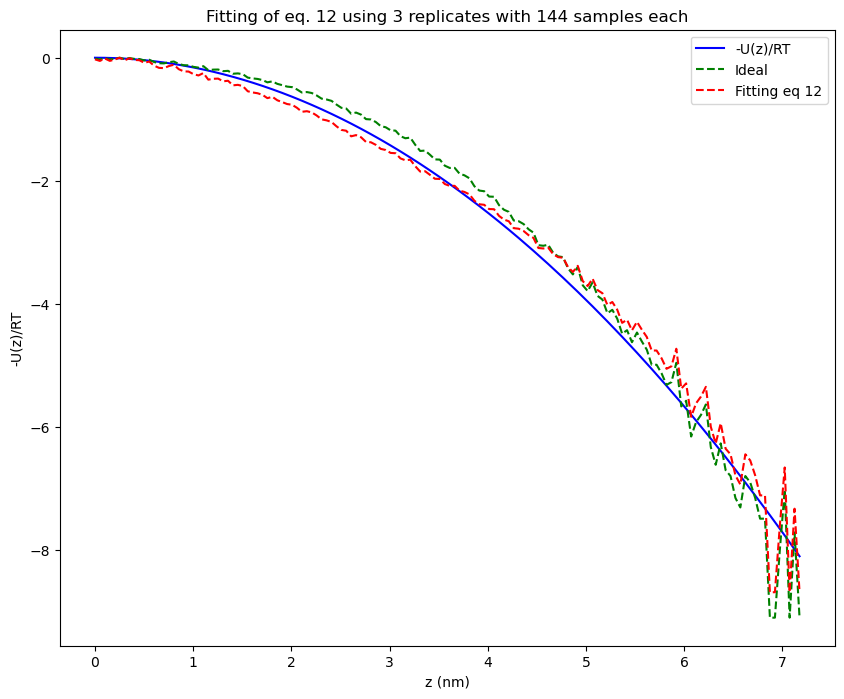

In [41]:
# plot the unweighted results
plt.figure(figsize = (10,8))
plt.plot(z_fit, y_values, 'b', label="-U(z)/RT")
plt.plot(z_fit, np.log(c_fit/np.max(c_fit)), 'g--', label="Ideal")
plt.plot(z_fit, calc_y(result_unweighted.x,c_fit), 'r--', label="Fitting eq 12")
plt.xlabel('z (nm)')
plt.ylabel('-U(z)/RT')
plt.title('Fitting of eq. 12 using 3 replicates with 144 samples each')
plt.legend()
plt.show()

Note BM: could maybe code up a funciton to check the above ^

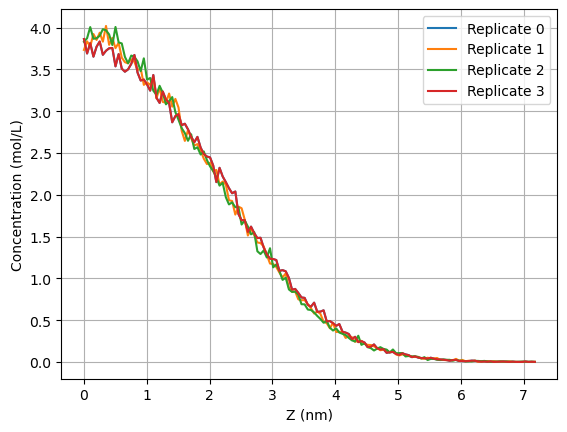

In [42]:
# Plot the concentration profiles (original and replicates)
plt.figure()
for i, c in enumerate(concentration_profiles):
    plt.plot(z, c, label="Replicate "+str(i))
plt.xlabel("Z (nm)")
plt.ylabel("Concentration (mol/L)")
plt.grid()
plt.legend()
plt.show()